In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
# from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
import thermoift.PLOT_SETTINGS as ps

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

try:
    from tabpfn import TabPFNRegressor
    from tabpfn.constants import ModelVersion
except ImportError as exc:
    raise ImportError(
        "tabpfn is not installed. Run `%pip install tabpfn` in a notebook cell, then rerun."
    ) from exc

In [2]:
csv_path = "interfacial_results_dataset_A1.csv"
combined_df = pd.read_csv(csv_path)

print(f"Loaded {csv_path} with shape: {combined_df.shape}")
print(f"\nP_dew statistics:")
print(combined_df["P_dew"].describe())

Loaded interfacial_results_dataset_A1.csv with shape: (19171, 74)

P_dew statistics:
count    19171.000000
mean        21.906458
std         17.547873
min          2.105356
25%          6.364315
50%         15.926816
75%         33.788807
max         73.568153
Name: P_dew, dtype: float64


In [3]:
target = "P_dew"

COMPONENTS = [
    "carbon dioxide",
    "hydrogen",
    "argon",
    "nitrogen",
    "methane",
    "oxygen",
    "carbon monoxide",
    "hydrogen sulfide",
]

z_columns = [f"z_{comp}" for comp in COMPONENTS]
feature_cols = [
    col for col in combined_df.columns
    if col in ["temperature", "pressure"] + z_columns
]

required_cols = feature_cols + [target]
df_model = combined_df[required_cols].dropna().copy()

X = df_model[feature_cols]
y = df_model[target]

print("Selected features:", feature_cols)
print(f"Rows after dropna on features + target: {len(df_model)}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']
Rows after dropna on features + target: 19171


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=85
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")

Training rows: 15336
Testing rows:  3835


In [5]:
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

tabpfn_model = TabPFNRegressor(
    random_state=85,
    ignore_pretraining_limits=True,
    fit_mode="fit_preprocessors",
)
tabpfn_model.fit(X_train, y_train)

y_pred_train = tabpfn_model.predict(X_train)
y_pred_test = tabpfn_model.predict(X_test)

print("TabPFN model training completed.")

TabPFN model training completed.


In [6]:
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

train_metrics = regression_metrics(y_train, y_pred_train)
test_metrics = regression_metrics(y_test, y_pred_test)

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
print("=" * 60)
print("TabPFN Model Performance for P_dew")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  R²:   {train_metrics['R2']:.6f}")
print(f"  RMSE: {train_metrics['RMSE']:.6f} bar")
print(f"  MAE:  {train_metrics['MAE']:.6f} bar")
print(f"\nTest Set:")
print(f"  R²:   {test_metrics['R2']:.6f}")
print(f"  RMSE: {test_metrics['RMSE']:.6f} bar")
print(f"  MAE:  {test_metrics['MAE']:.6f} bar")
metrics_df

TabPFN Model Performance for P_dew

Training Set:
  R²:   0.999997
  RMSE: 0.028416 bar
  MAE:  0.016523 bar

Test Set:
  R²:   0.999998
  RMSE: 0.026255 bar
  MAE:  0.015747 bar


,R2,RMSE,MAE
Train,0.999997,0.028416,0.016523
Test,0.999998,0.026255,0.015747


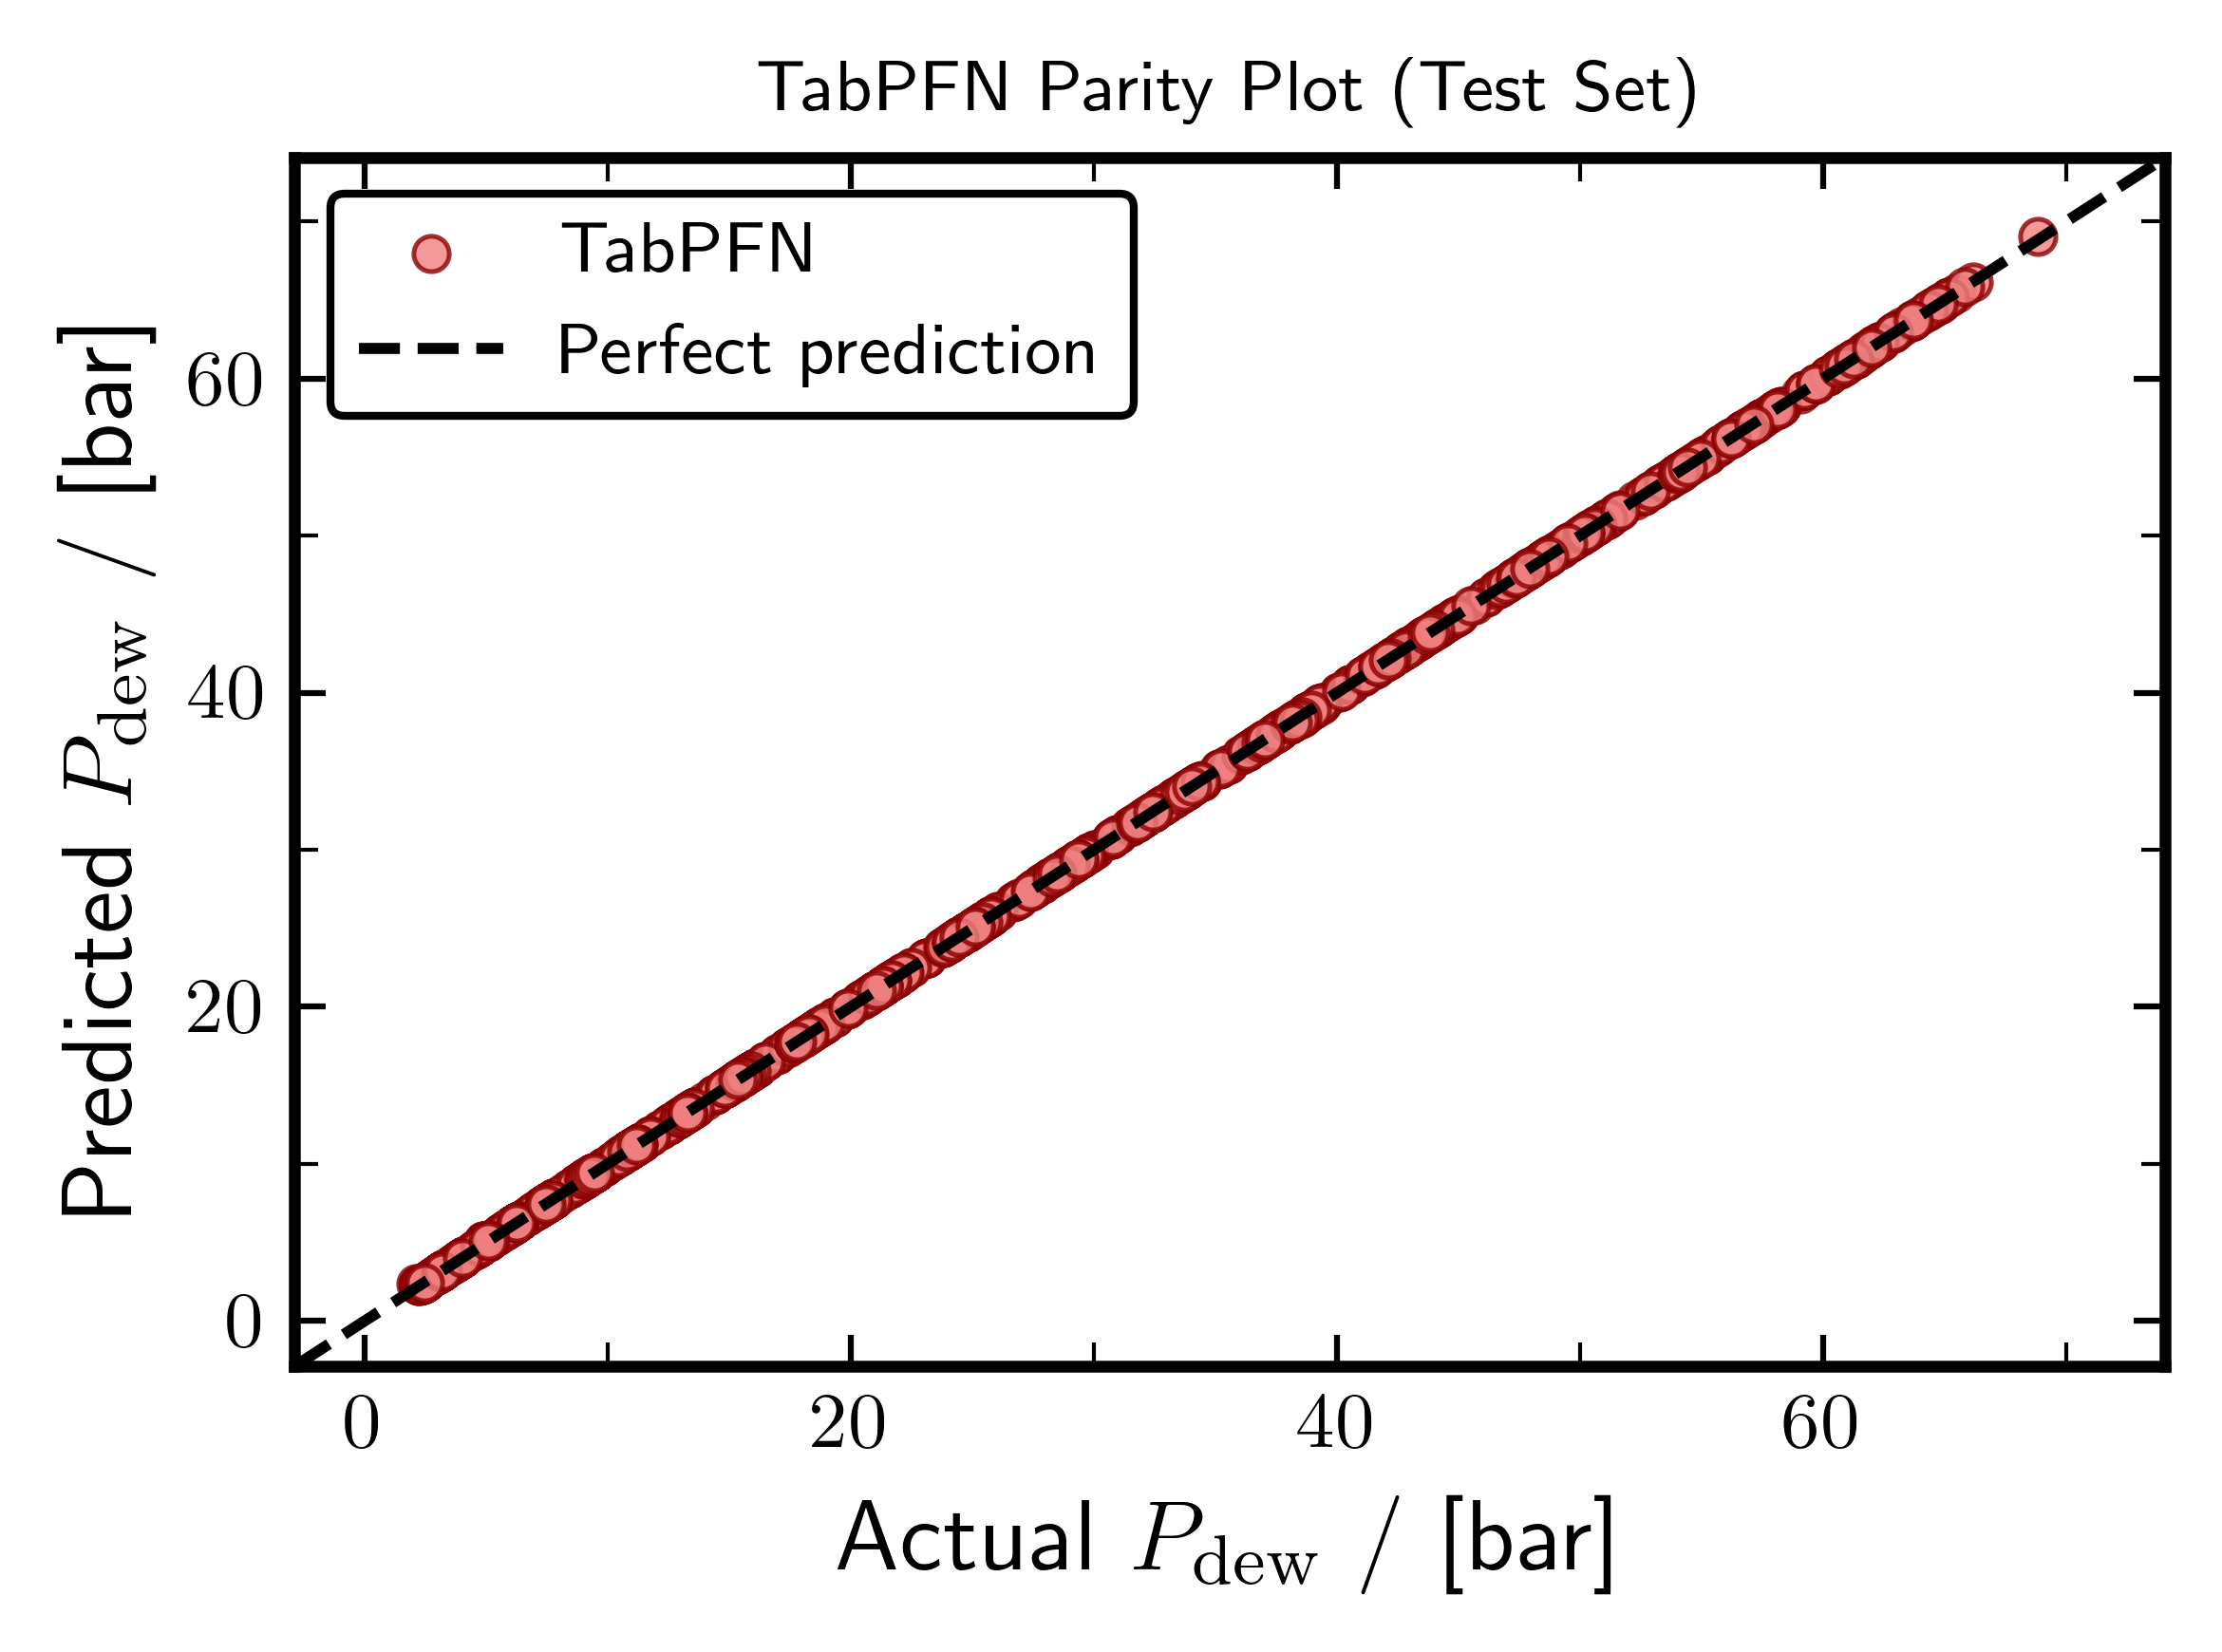

In [7]:
# Parity plot
fig, ax = ps.plot_init()

lims = [
    min(y_test.min(), np.min(y_pred_test)),
    max(y_test.max(), np.max(y_pred_test))
]
lims = [lims[0] - 5, lims[1] + 5]

ax.scatter(
    y_test, y_pred_test,
    alpha=0.8, s=20,
    facecolors="lightcoral",
    edgecolors="darkred",
    linewidths=0.6,
    label="TabPFN"
)

ax.plot(lims, lims, "k--", linewidth=1.4, label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel(r"Actual $P_{\mathrm{dew}}$ / [bar]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Predicted $P_{\mathrm{dew}}$ / [bar]", fontsize=ps.label_fontsize * 0.9)
ax.set_title(r"TabPFN Parity Plot (Test Set)", fontsize=ps.title_fontsize * 0.75, fontweight="bold")

ps.apply_axis_style(ax)
# dummy_r2 = Line2D([], [], linestyle="none", label=rf"$R^2$ = {test_metrics['R2']:.4f}")

handles, labels = ax.get_legend_handles_labels()
# handles.append(dummy_r2)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.65,
    loc="upper left",
    edgecolor="black",
    framealpha=1.0
)

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "tabpfn_P_dew_parity_plot")
plt.show()

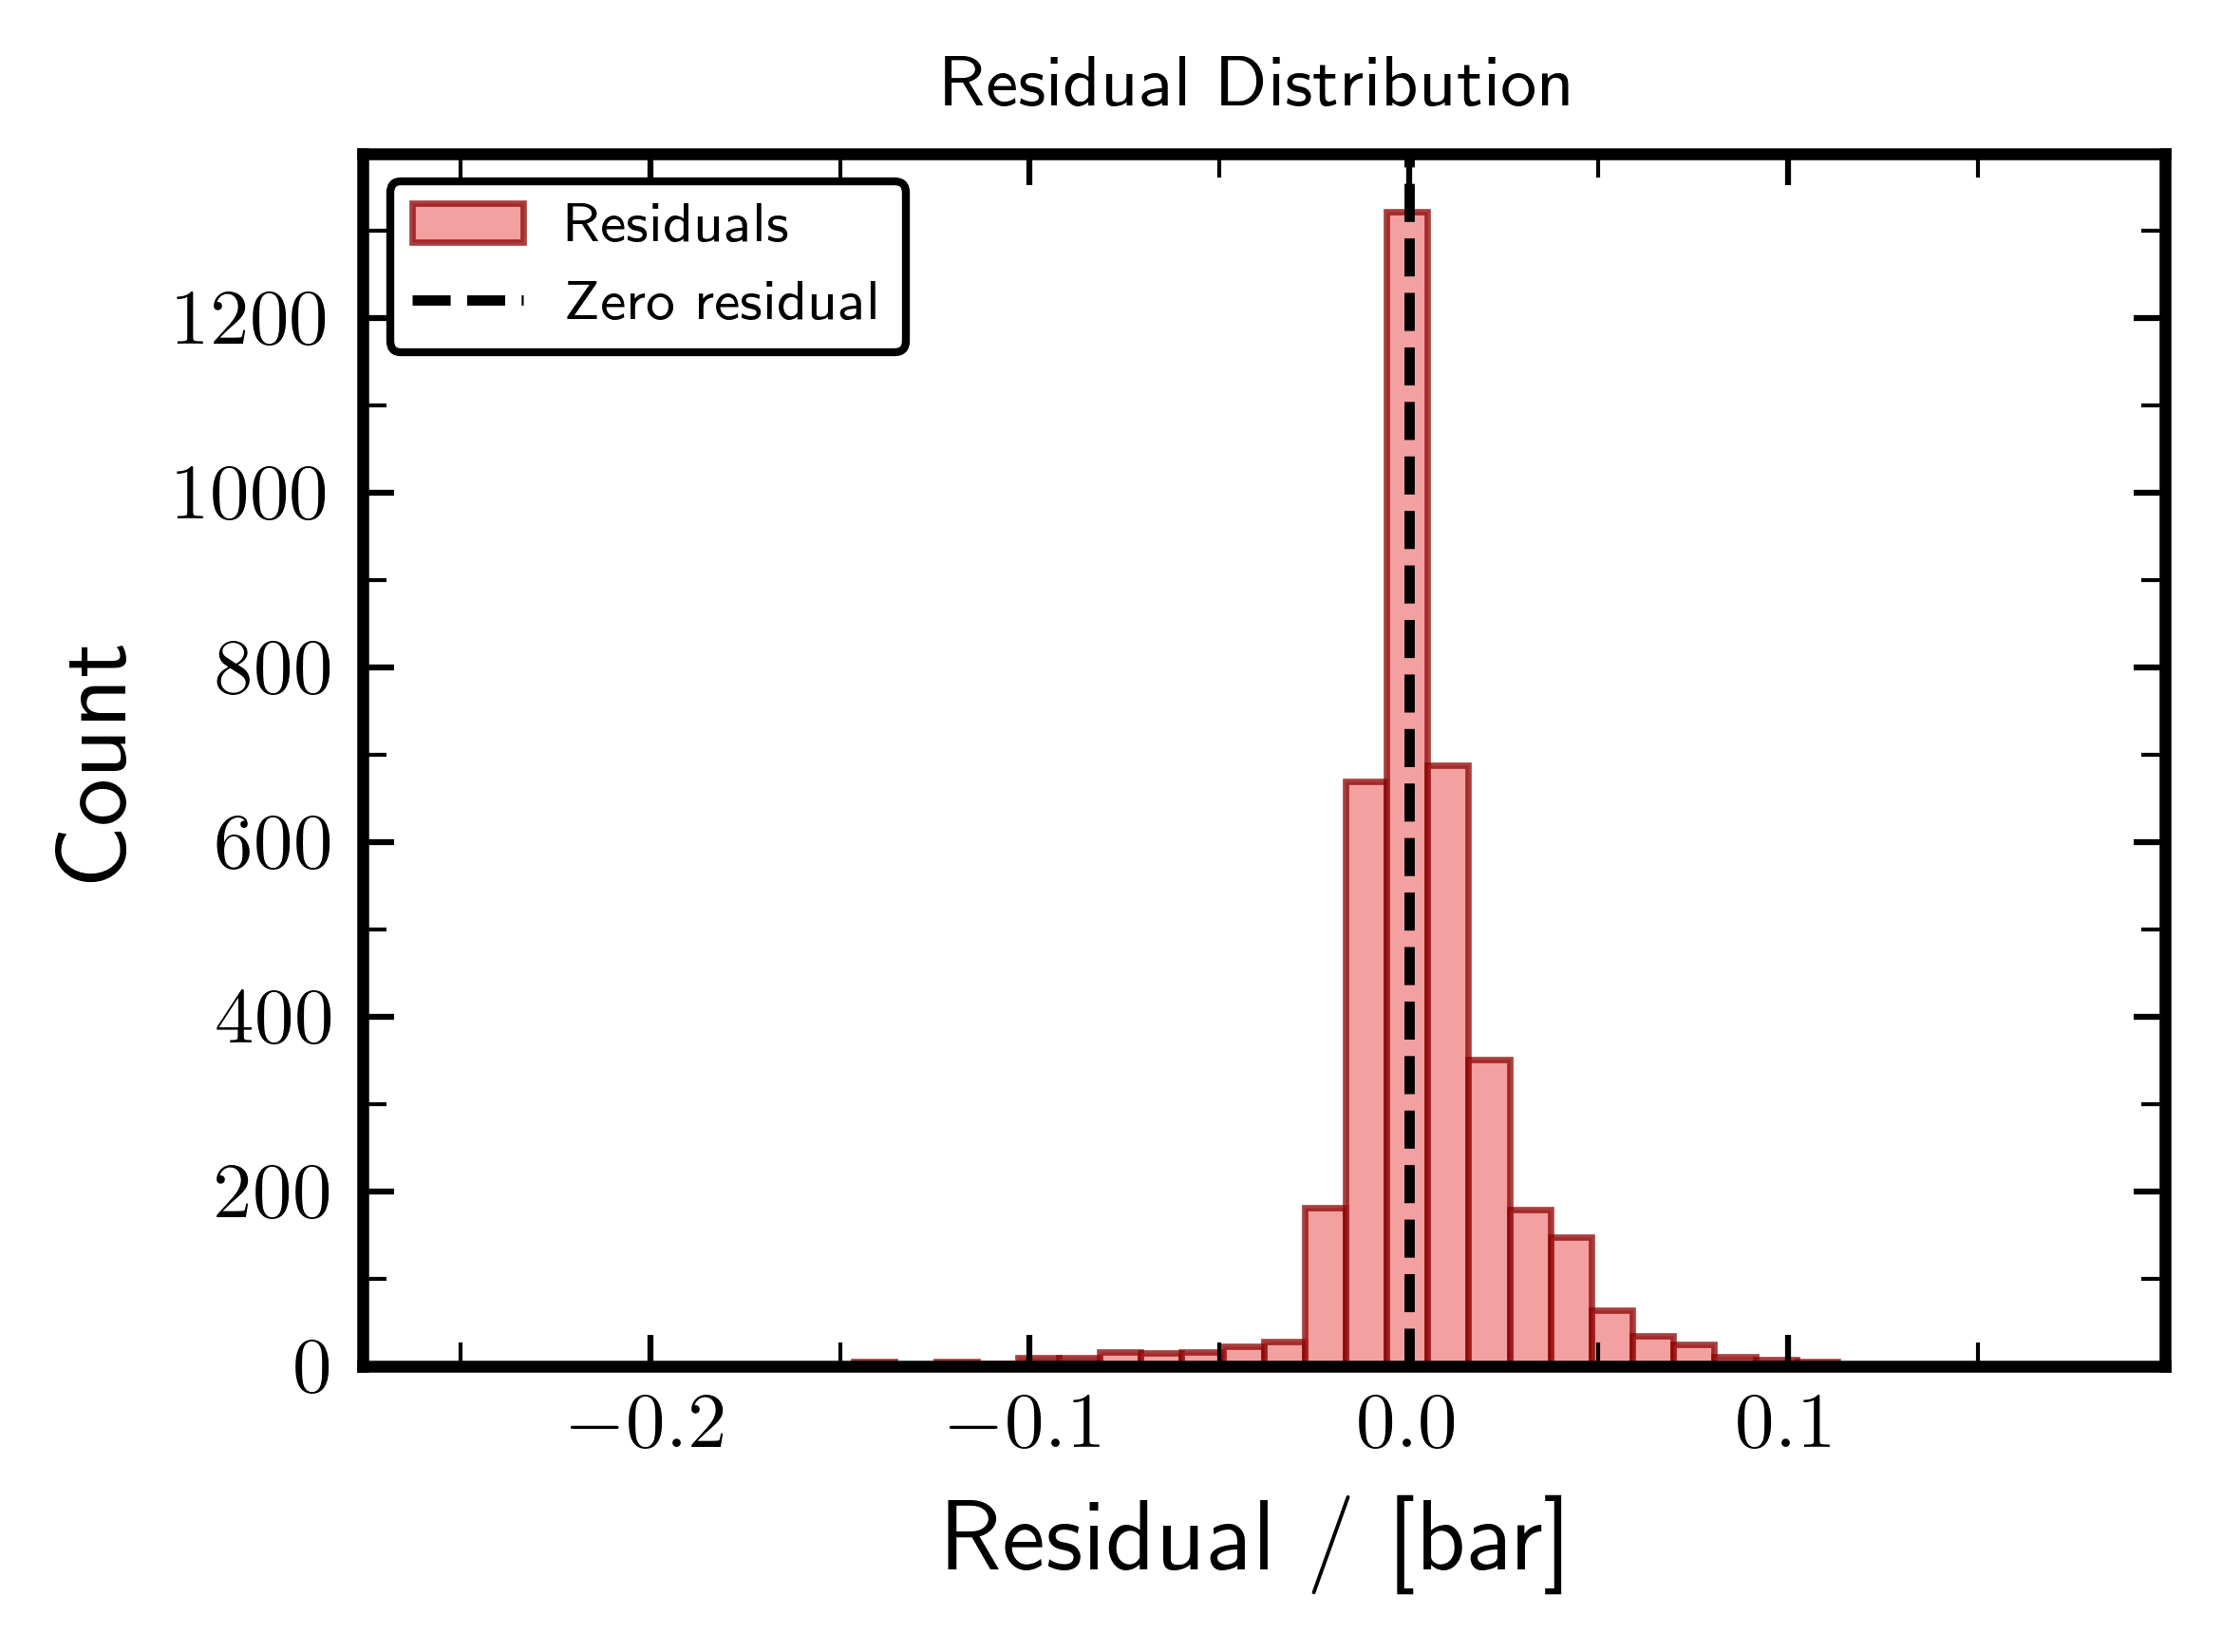

In [8]:
# Residual distribution
residuals = y_test.values - y_pred_test

fig, ax = ps.plot_init()

ax.hist(
    residuals,
    bins=40,
    alpha=0.75,
    color="lightcoral",
    edgecolor="darkred",
    linewidth=0.8,
    label="Residuals"
)

ax.axvline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")

mean_resid = residuals.mean()
std_resid = residuals.std()

ax.set_xlabel(r"Residual / [bar]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Count", fontsize=ps.label_fontsize * 0.9)
ax.set_title(r"Residual Distribution", fontsize=ps.title_fontsize * 0.75, fontweight="bold")

# dummy_mean = Line2D([], [], linestyle="none", label=rf"Mean = {mean_resid:.4f} bar")
# dummy_std  = Line2D([], [], linestyle="none", label=rf"Std Dev = {std_resid:.4f} bar")
# dummy_rmse = Line2D([], [], linestyle="none", label=rf"RMSE = {test_metrics['RMSE']:.4f} bar")

handles, labels = ax.get_legend_handles_labels()
# handles.extend([dummy_mean, dummy_std, dummy_rmse])

ps.apply_axis_style(ax)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.5,
    loc="upper left",
    edgecolor="black",
    facecolor="white",
    framealpha=1.0
)

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "tabpfn_P_dew_residual_distribution")
plt.show()

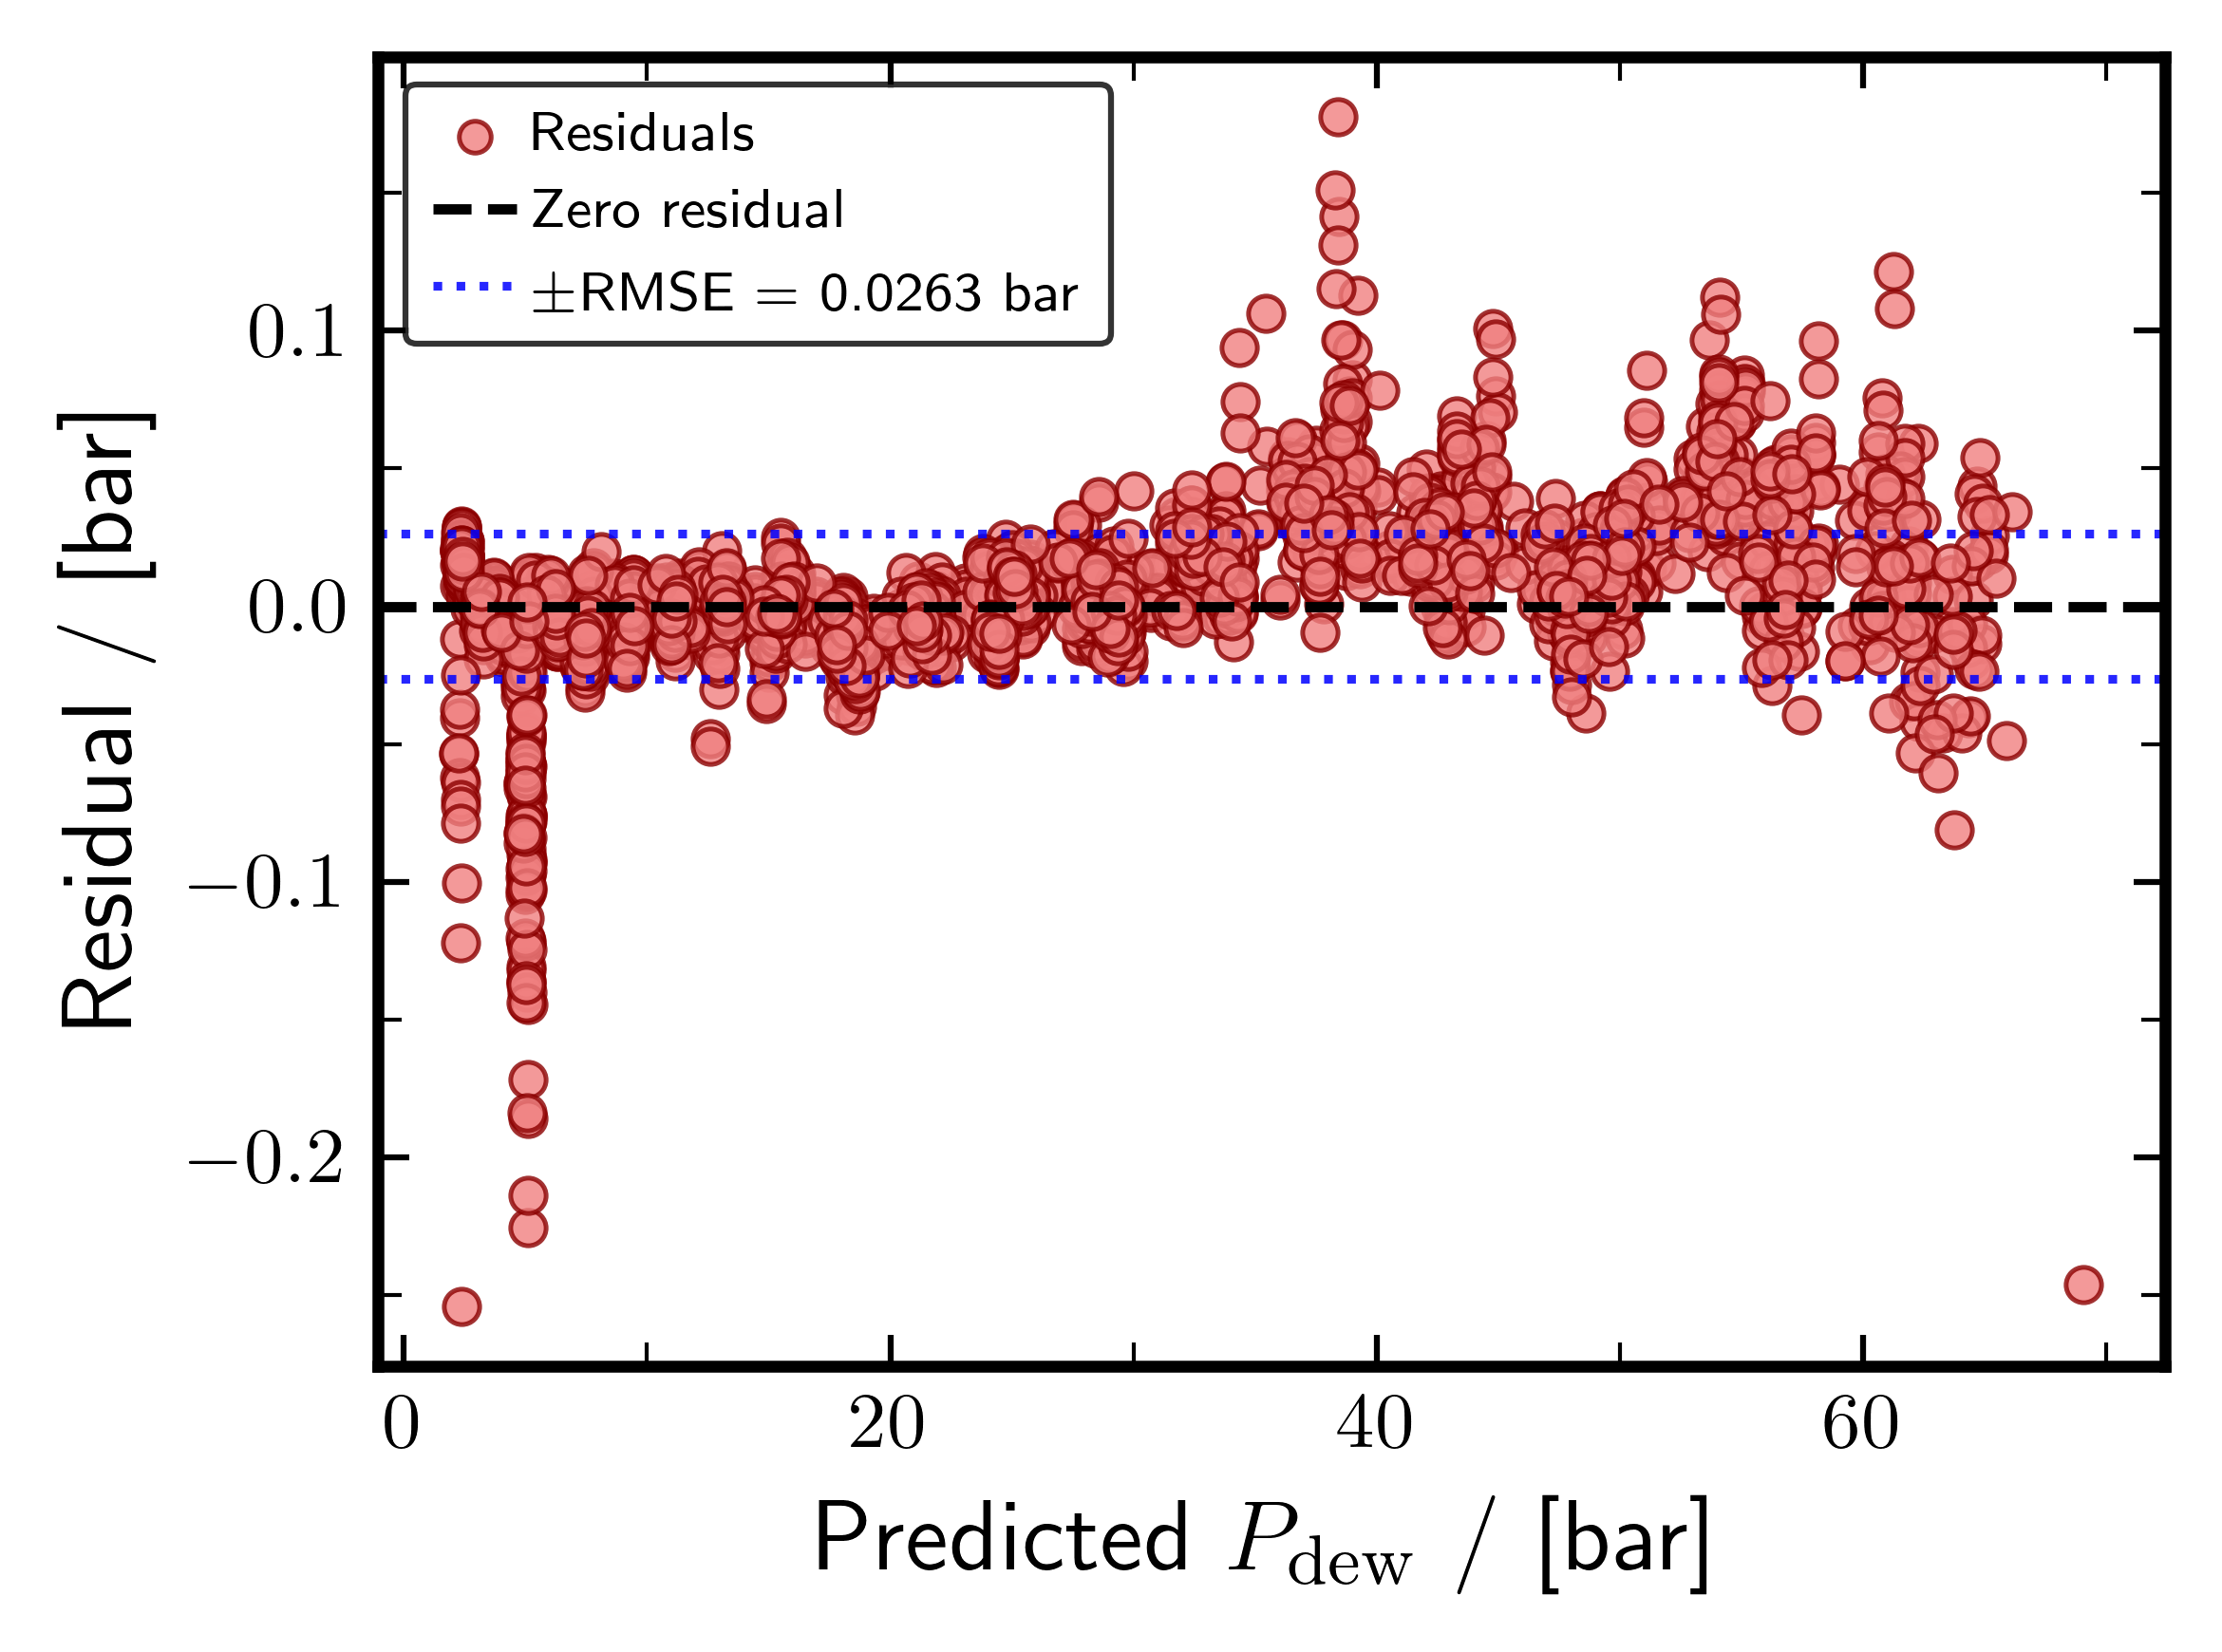

In [9]:
# Residuals vs Predicted
fig, ax = ps.plot_init()

ax.scatter(y_pred_test, residuals, alpha=0.8, s=20, facecolors="lightcoral", edgecolors="darkred", linewidths=0.6, label="Residuals")

ax.axhline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")
ax.axhline(test_metrics['RMSE'], color="blue", linewidth=1.1, linestyle=":", alpha=0.85, label=rf"$\pm$RMSE = {test_metrics['RMSE']:.4f} bar")
ax.axhline(-test_metrics['RMSE'], color="blue", linewidth=1.1, linestyle=":", alpha=0.85)

ax.set_xlabel(r"Predicted $P_{\mathrm{dew}}$ / [bar]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Residual / [bar]", fontsize=ps.label_fontsize * 0.9)

ps.apply_axis_style(ax)
ps.style_legend(ax, fontsize=ps.label_fontsize * 0.5, loc="upper left")

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "tabpfn_P_dew_residual_vs_predicted")
plt.show()

In [10]:
# 5-fold Cross-Validation
print("Running 5-fold cross-validation (this may take a while)...")
cv_scores = cross_val_score(tabpfn_model, X, y, cv=5, scoring='r2')

print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Running 5-fold cross-validation (this may take a while)...



5-FOLD CROSS-VALIDATION RESULTS
Cross-Validation R² Scores: [0.99263553 0.99873219 0.99721389 0.99824459 0.99964104]
Mean CV R²: 0.9973 (+/- 0.0049)


In [11]:
print("=" * 70)
print("SUMMARY: TabPFN Model for P_dew Prediction")
print("=" * 70)
print(f"\nModel: TabPFNRegressor")
print(f"Features used: {feature_cols}")
print(f"\nPerformance Metrics (Training Set):")
print(f"  - R²:   {train_metrics['R2']:.6f}")
print(f"  - RMSE: {train_metrics['RMSE']:.6f} bar")
print(f"  - MAE:  {train_metrics['MAE']:.6f} bar")
print(f"\nPerformance Metrics (Test Set):")
print(f"  - R²:   {test_metrics['R2']:.6f}")
print(f"  - RMSE: {test_metrics['RMSE']:.6f} bar")
print(f"  - MAE:  {test_metrics['MAE']:.6f} bar")
print(f"\nCross-Validation:")
print(f"  - Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

SUMMARY: TabPFN Model for P_dew Prediction

Model: TabPFNRegressor
Features used: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Performance Metrics (Training Set):
  - R²:   0.999997
  - RMSE: 0.028416 bar
  - MAE:  0.016523 bar

Performance Metrics (Test Set):
  - R²:   0.999998
  - RMSE: 0.026255 bar
  - MAE:  0.015747 bar

Cross-Validation:
  - Mean CV R²: 0.9973 (+/- 0.0049)


In [12]:
# Save predictions
pred_df = X_test.copy()
pred_df["P_dew_actual"] = y_test.values
pred_df["P_dew_pred_tabpfn"] = y_pred_test

pred_df.to_csv("tabpfn_P_dew_test_predictions.csv", index=False)
print("Saved predictions to tabpfn_P_dew_test_predictions.csv")
pred_df.head()

Saved predictions to tabpfn_P_dew_test_predictions.csv


,temperature,pressure,z_carbon dioxide,z_hydrogen,z_nitrogen,z_argon,z_methane,z_oxygen,z_carbon monoxide,z_hydrogen sulfide,P_dew_actual,P_dew_pred_tabpfn
4330,275.0,37.256439,0.990000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.0,36.995835,36.975372
13242,245.0,15.527731,0.980000,0.014697,0.000000,0.000000,0.002563,0.000333,0.002407,0.0,15.527631,15.529096
8506,250.0,19.386534,0.990000,0.000000,0.000000,0.003023,0.003007,0.003970,0.000000,0.0,18.020334,18.024023
12605,210.0,8.725639,0.949999,0.000410,0.003068,0.000000,0.024408,0.022115,0.000000,0.0,4.103417,4.101804
13969,220.0,7.891495,0.960000,0.000000,0.000000,0.030000,0.000000,0.000000,0.010000,0.0,6.293132,6.285078
